In [12]:
import sys
sys.path.append("../src")


In [13]:
import pandas as pd

df = pd.read_csv("../data/processed/forecast_features.csv", parse_dates=["date"])

TARGET = "sales"
DROP_COLUMNS = ["id", "date", "sales"]

numeric_features = df.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
numeric_features = [c for c in numeric_features if c not in DROP_COLUMNS]

split_date = "2017-01-01"

train = df[df["date"] < split_date]
valid = df[df["date"] >= split_date]

X_train = train[numeric_features]
X_valid = valid[numeric_features]

y_train = train[TARGET]
y_valid = valid[TARGET]


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_valid)


In [15]:
from visualization import plot_predictions


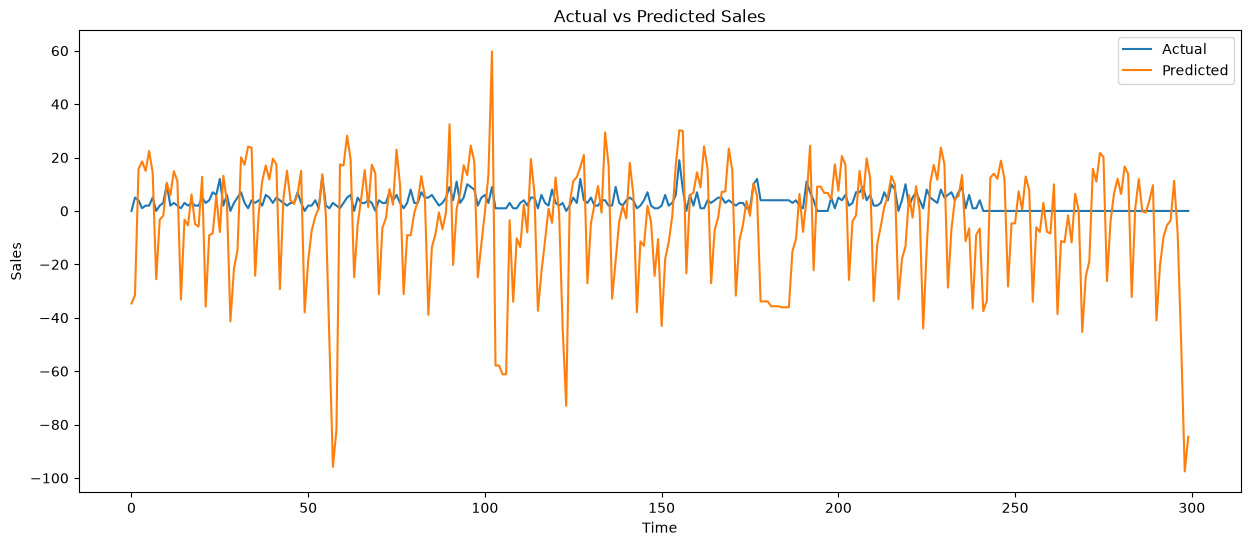

In [16]:
plot_predictions(y_valid, pred)
